# 04 - Calibración, umbral y evaluación

Calibración de probabilidades (Platt/isotonic por Brier), optimización del umbral maximizando ganancia en validación, evaluación out-of-time vs. baselines e interpretabilidad (SHAP).

In [1]:
import sys
sys.path.append("..")
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data import load_raw, clean
from src.features import temporal_split, NUM_FEATURES, CAT_LOW, CAT_HIGH
from src.model import build_xgb
from src import utils
from src.utils import PALETA

utils.set_style()

df = clean(load_raw("../data/dataset.csv"))
train, val, test = temporal_split(df, train_frac=0.7, val_frac=0.15)
FEATURES = NUM_FEATURES + CAT_LOW + CAT_HIGH
X_train, y_train = train[FEATURES], train["fraude"]
X_val,   y_val   = val[FEATURES],   val["fraude"]
X_test,  y_test  = test[FEATURES],  test["fraude"]

spw = (y_train == 0).sum() / (y_train == 1).sum()
xgb = build_xgb(scale_pos_weight=spw).fit(X_train, y_train)


## Calibración de probabilidades

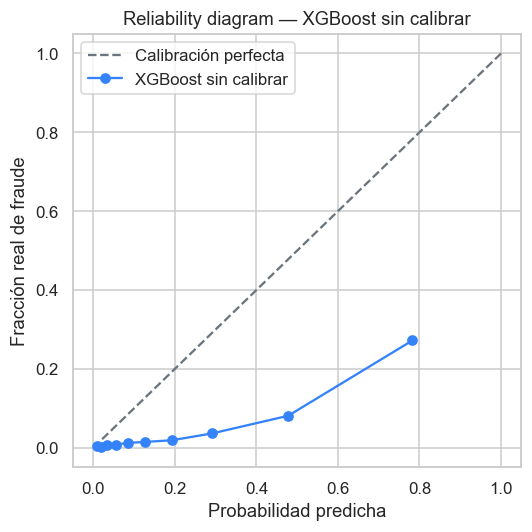

Brier score (sin calibrar): 0.0882


In [2]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

p_val = xgb.predict_proba(X_val)[:, 1]
frac_real, prob_pred = calibration_curve(y_val, p_val, n_bins=10, strategy="quantile")

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([0, 1], [0, 1], "--", color=PALETA["neutro"], label="Calibración perfecta")
ax.plot(prob_pred, frac_real, "o-", color=PALETA["principal"], label="XGBoost sin calibrar")
ax.set_xlabel("Probabilidad predicha")
ax.set_ylabel("Fracción real de fraude")
ax.set_title("Reliability diagram — XGBoost sin calibrar")
ax.legend()
plt.tight_layout()
plt.show()

print("Brier score (sin calibrar):", round(brier_score_loss(y_val, p_val), 4))

In [3]:
from sklearn.calibration import CalibratedClassifierCV

calibradores, briers = {}, {}
for metodo in ["sigmoid", "isotonic"]:
    cal = CalibratedClassifierCV(xgb, method=metodo, cv="prefit")
    cal.fit(X_val, y_val)                       # calibra usando validación
    p = cal.predict_proba(X_val)[:, 1]
    briers[metodo] = brier_score_loss(y_val, p)
    calibradores[metodo] = cal
    print(f"{metodo:9} → Brier: {briers[metodo]:.4f}")

print(f"sin calibrar → Brier: {brier_score_loss(y_val, p_val):.4f}")

mejor = min(briers, key=briers.get)
xgb_cal = calibradores[mejor]
print("Mejor calibrador:", mejor)

sigmoid   → Brier: 0.0340
isotonic  → Brier: 0.0325
sin calibrar → Brier: 0.0882
Mejor calibrador: isotonic


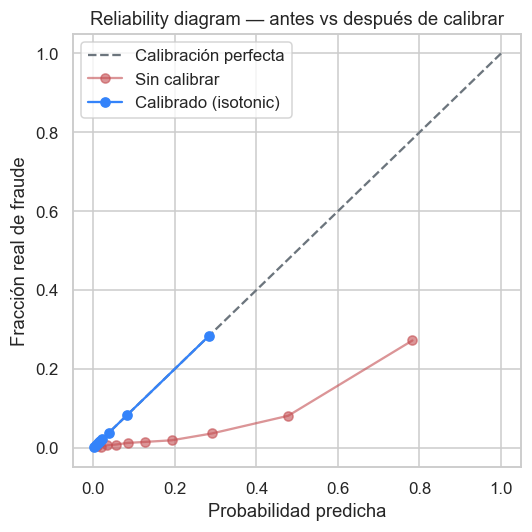

In [4]:
p_val_cal = xgb_cal.predict_proba(X_val)[:, 1]
frac_c, prob_c = calibration_curve(y_val, p_val_cal, n_bins=10, strategy="quantile")

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([0, 1], [0, 1], "--", color=PALETA["neutro"], label="Calibración perfecta")
ax.plot(prob_pred, frac_real, "o-", color="#C44E52", alpha=0.6, label="Sin calibrar")
ax.plot(prob_c, frac_c, "o-", color=PALETA["principal"], label=f"Calibrado ({mejor})")
ax.set_xlabel("Probabilidad predicha")
ax.set_ylabel("Fracción real de fraude")
ax.set_title("Reliability diagram — antes vs después de calibrar")
ax.legend()
plt.tight_layout()
plt.show()

XGBoost, al usar `scale_pos_weight`, produce probabilidades **descalibradas**
(sobreestima el fraude): sin calibrar, cuando predice 0,78 la fracción real es
~0,27. Esto invalidaría el umbral económico, que requiere probabilidades
reales.

Se calibra sobre validación comparando dos métodos y eligiendo por Brier score:

| Método       | Brier  |
|--------------|--------|
| Sin calibrar | 0,0882 |
| Sigmoid      | 0,0340 |
| **Isotonic** | **0,0325** |

Isotonic reduce el Brier un ~63% y deja las probabilidades sobre la diagonal.
Estas probabilidades calibradas son las que se usan para el umbral de ganancia.

## Umbral de ganancia

In [5]:
from src.profit import find_best_threshold, profit_from_threshold, BREAK_EVEN_THRESHOLD

monto_val = val["monto"].values

mejor_umbral, mejor_ganancia, grid, ganancias = find_best_threshold(
    y_val, monto_val, p_val_cal
)

print(f"Umbral óptimo (val): {mejor_umbral:.2f}")
print(f"Ganancia con umbral óptimo:  ${mejor_ganancia:,.0f}")
print(f"Ganancia con umbral 0.20:    "
      f"${profit_from_threshold(y_val, monto_val, p_val_cal, BREAK_EVEN_THRESHOLD):,.0f}")

Umbral óptimo (val): 0.18
Ganancia con umbral óptimo:  $168,812
Ganancia con umbral 0.20:    $166,893


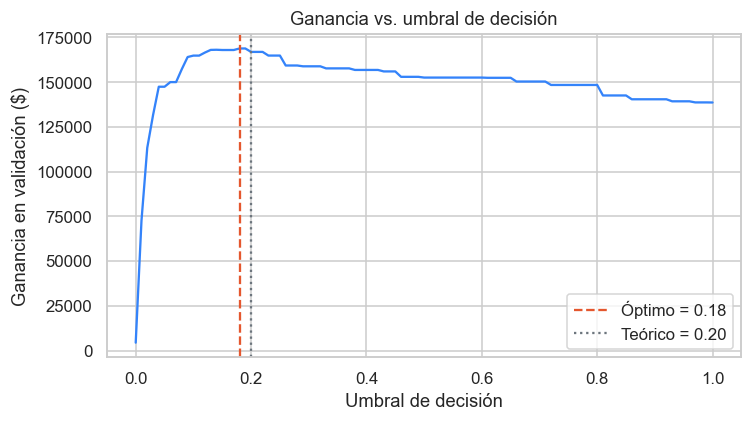

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(grid, ganancias, color=PALETA["principal"])
ax.axvline(mejor_umbral, color=PALETA["acento"], ls="--", label=f"Óptimo = {mejor_umbral:.2f}")
ax.axvline(BREAK_EVEN_THRESHOLD, color=PALETA["neutro"], ls=":", label="Teórico = 0.20")
ax.set_xlabel("Umbral de decisión")
ax.set_ylabel("Ganancia en validación ($)")
ax.set_title("Ganancia vs. umbral de decisión")
ax.legend()
plt.tight_layout()
plt.show()

## Evaluación